# Random Search

The random seach method of hyper parameter tuning is, well random\. It involves creating your list of possible hyperparameter variable values, and then the tuner will select random combinations of the possible values a set number of times\. This method contains no internal code to allow the tuning to limit its future value combinations\. This means that it is not capable of learning from past iterations nore does it have the small limitation of not being able to repeat previous combinations of values\.  

## Imports

In [1]:
import pandas as pd
import numpy as np
import time

from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.utils import shuffle

from xgboost import XGBRegressor

import matplotlib.pyplot as plt
import math

### Loading and Shuffling Data

In [2]:
df = pd.read_csv("housing_cleaned.csv")
df = shuffle(df, random_state=42)

### Split Dataset

In [3]:
X = df.drop(columns=['price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

## Baseline Model:

Here we are building a simple baseline unturned XGRegressor model\. This same code appears at the top of most of the note books and is there to locally have a comparison value with the tuned model that is being created below it\. 

In [4]:
baseline = XGBRegressor(
    objective='reg:squarederror', 
    random_state=42,
    n_jobs = -1    
)

baseline.fit(X_train, y_train)

baseline_pred = baseline.predict(X_test)

baseline_rmse = mean_squared_error(y_test, baseline_pred, squared=False)

print("Baseline RMSE (log scale):", baseline_rmse)

Baseline RMSE (log scale): 0.16340095299614865


## Random Search

### Set Possible Hyperparameter values

In [5]:
param_dist = {
    'n_estimators': [300, 350, 400, 450, 500],
    'max_depth': [5, 6],
    'learning_rate': [0.01, 0.03, 0.05],
    'subsample': [0.7, 0.8],
    'colsample_bytree': [0.7, 0.8],
    'min_child_weight': [3] 
}

### Set up the Random Search

In [6]:
# Create basic model
xgb = XGBRegressor(
    objective = 'reg:squarederror',
    random_state = 42,
    n_jobs = -1
)

# Create the Random Search element
random_search = RandomizedSearchCV(
    estimator=xgb,
    param_distributions=param_dist,
    n_iter=200,
    scoring='neg_mean_squared_error',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=1   # 🔥 TEMPORARY FIX (important)
)

### Fit the Model

Here we are going to fit our new Random Search model to the training data\. While doing this we will be timing how long this process takes\. The purpose of this is to give us a realitive comparison value when looking at the other model that use different tuning methods\. 

In [7]:
start = time.time()

In [8]:
random_search.fit(X_train, y_train)

Fitting 5 folds for each of 120 candidates, totalling 600 fits
/root/venv/lib/python3.11/site-packages/sklearn/model_selection/_search.py:307: UserWarning: The total space of parameters 120 is smaller than n_iter=200. Running 120 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   0.7s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   0.9s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   1.1s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   1.0s
[CV] END colsample_bytree=0.7, learning_rate=0.01, max_depth=5, min_child_weight=3, n_estimators=300, subsample=0.7; total time=   0.6s
[CV] END colsample

RandomizedSearchCV(cv=5,
                   estimator=XGBRegressor(base_score=None, booster=None,
                                          callbacks=None,
                                          colsample_bylevel=None,
                                          colsample_bynode=None,
                                          colsample_bytree=None, device=None,
                                          early_stopping_rounds=None,
                                          enable_categorical=False,
                                          eval_metric=None, feature_types=None,
                                          feature_weights=None, gamma=None,
                                          grow_policy=None,
                                          importance_type=None,
                                          interaction_constraint...
                                          monotone_constraints=None,
                                          multi_strategy=None,
                                          n_estimators=None, n_jobs=-1,
                                          num_parallel_tree=None, ...),
                   n_iter=200, n_jobs=1,
                   param_distributions={'colsample_bytree': [0.7, 0.8],
                                        'learning_rate': [0.01, 0.03, 0.05],
                                        'max_depth': [5, 6],
                                        'min_child_weight': [3],
                                        'n_estimators': [300, 350, 400, 450,
                                                         500],
                                        'subsample': [0.7, 0.8]},
                   random_state=42, scoring='neg_mean_squared_error',
                   verbose=2)

In [9]:
end = time.time()

print(f"Total time: {(end - start)/60:.2f} minutes")

Total time: 14.14 minutes


### Extract Best Hyperparameter Values from Tuning

Now that we are finish tuning this model we can extract what the best combination of values the random\_search was able to locate\. This does not mean that we are finished\. We now have to use these value in the creation of our final model\.

In [10]:
best_params = random_search.best_params_

print('Best Params:')
print(best_params)

Best Params:
{'subsample': 0.8, 'n_estimators': 500, 'min_child_weight': 3, 'max_depth': 6, 'learning_rate': 0.05, 'colsample_bytree': 0.7}


### Create Model Using Best Parameters

Its time to create our final model using the parameters that our tuning just found\. We will start the process with another data split, but this time the result will be us creating a validation dataset\. 

In [11]:
X_train2, X_val, y_train2, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

In [12]:
best_model = XGBRegressor(
    **best_params,
    objective='reg:squarederror',
    random_state=42,
    early_stopping_rounds=50 
)

best_model.fit(
    X_train2,
    y_train2,
    eval_set=[(X_train2, y_train2), (X_val, y_val)],
    verbose=False
)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.7, device=None, early_stopping_rounds=50,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
             max_leaves=None, min_child_weight=3, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=500,
             n_jobs=None, num_parallel_tree=None, ...)

### Results

In [13]:
y_pred = best_model.predict(X_test)
rmse_log = mean_squared_error(y_test, y_pred, squared = False)
print('Test RMSE (log scale):', rmse_log)

Test RMSE (log scale): 0.15886170044463868


In [14]:
# Convert Log RMSE to something easier to interpert.
print(math.exp(rmse_log))

1.1721758240749591


### Visualize the Results

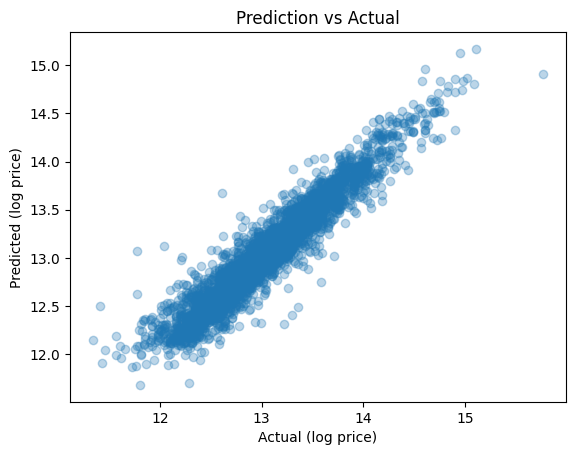

In [15]:
plt.figure()
plt.scatter(y_test, y_pred, alpha = 0.3)
plt.xlabel("Actual (log price)")
plt.ylabel("Predicted (log price)")
plt.title("Prediction vs Actual")
plt.show()

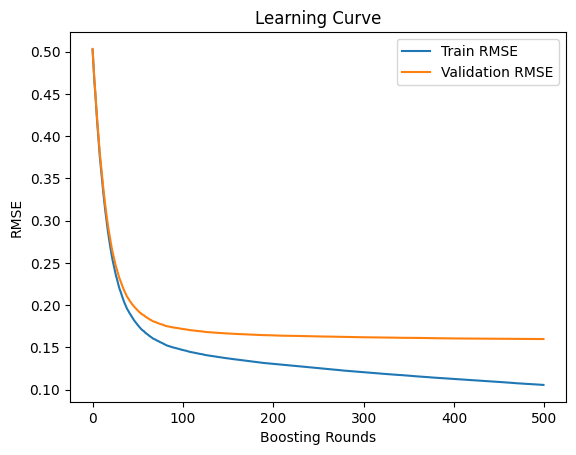

In [16]:
results = best_model.evals_result()

train_rmse = results['validation_0']['rmse']
val_rmse = results['validation_1']['rmse']

plt.figure()
plt.plot(train_rmse, label='Train RMSE')
plt.plot(val_rmse, label='Validation RMSE')
plt.xlabel('Boosting Rounds')
plt.ylabel('RMSE')
plt.title('Learning Curve')
plt.legend()
plt.show()

Since the Validation curve is above the training curve the model is not overfitting\. As far as underfittings, the end of the graph show as different between the lines of rougly and RMSE of 0\.07\. This is a small value, so we can determine this model is not underfitting\. 

### How Important is Each Variable

In [17]:
importance = best_model.feature_importances_
features = X.columns

imp_df = pd.DataFrame({
    'feature' : features,
    'importance': importance
}).sort_values(by = 'importance', ascending = False)

print(imp_df.head(10))

          feature  importance
8           grade    0.280248
12            lat    0.088737
2     sqft_living    0.083935
20  zipcode_98004    0.041947
5      waterfront    0.031950
57  zipcode_98092    0.030717
6            view    0.026889
30  zipcode_98023    0.022401
18  zipcode_98002    0.017266
41  zipcode_98039    0.016826


In [18]:
print(best_model.best_iteration)

493


In [19]:
best_round = np.argmin(val_rmse)
print("Best round from curve:", best_round)

Best round from curve: 493


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=89799500-4443-401d-b5a6-3a6742d3b89e' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>